# 03 · Escalado de Variables
**Proyecto:** Predicción de abandono de clientes – Telco Customer Churn

---
## Objetivo de este notebook
Aplicar escalado de variables numéricas para los modelos que lo requieren.
No todos los algoritmos necesitan escalado — se analiza el impacto en cada caso.

**Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')

**¿Por qué escalar?**

Las variables numéricas del dataset tienen escalas muy distintas:
- `tenure`: valores entre 0 y 72
- `MonthlyCharges`: valores entre 18 y 118
- `TotalCharges`: valores entre 0 y 8684

La **Regresión Logística** es sensible a estas diferencias de escala porque optimiza mediante gradiente; variables con valores grandes dominan el cálculo y el modelo puede no converger correctamente.

El **Árbol de Decisión** en cambio es invariante al escalado: sus decisiones se basan en umbrales de corte, no en magnitudes absolutas.

In [3]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(X_train[numeric_cols].describe().round(2))

        tenure  MonthlyCharges  TotalCharges
count  4225.00         4225.00       4225.00
mean     32.29           64.78       2284.04
std      24.67           29.99       2280.33
min       0.00           18.40          0.00
25%       9.00           35.75        383.65
50%      29.00           70.40       1380.10
75%      56.00           89.75       3825.85
max      72.00          118.75       8684.80


**Aplicar StandardScaler**

`StandardScaler` transforma cada variable para que tenga media=0 y desviación estándar=1.

Se eligió StandardScaler por sobre MinMaxScaler y RobustScaler porque el análisis de outliers
(notebook 01) no detectó valores extremos que distorsionen la media, haciendo que StandardScaler
sea suficiente y apropiado para este dataset.

In [4]:
scaler = StandardScaler()

In [5]:
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

In [6]:
# fit_transform en train: aprende media y std, luego transforma
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# transform en val y test: solo aplica la transformación aprendida en train
X_val_scaled[numeric_cols]   = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])


In [7]:

print('Estadísticas DESPUÉS del escalado (train):')
print(X_train_scaled[numeric_cols].describe().round(2))

Estadísticas DESPUÉS del escalado (train):
        tenure  MonthlyCharges  TotalCharges
count  4225.00         4225.00       4225.00
mean     -0.00           -0.00          0.00
std       1.00            1.00          1.00
min      -1.31           -1.55         -1.00
25%      -0.94           -0.97         -0.83
50%      -0.13            0.19         -0.40
75%       0.96            0.83          0.68
max       1.61            1.80          2.81


**Visualización del efecto del escalado**

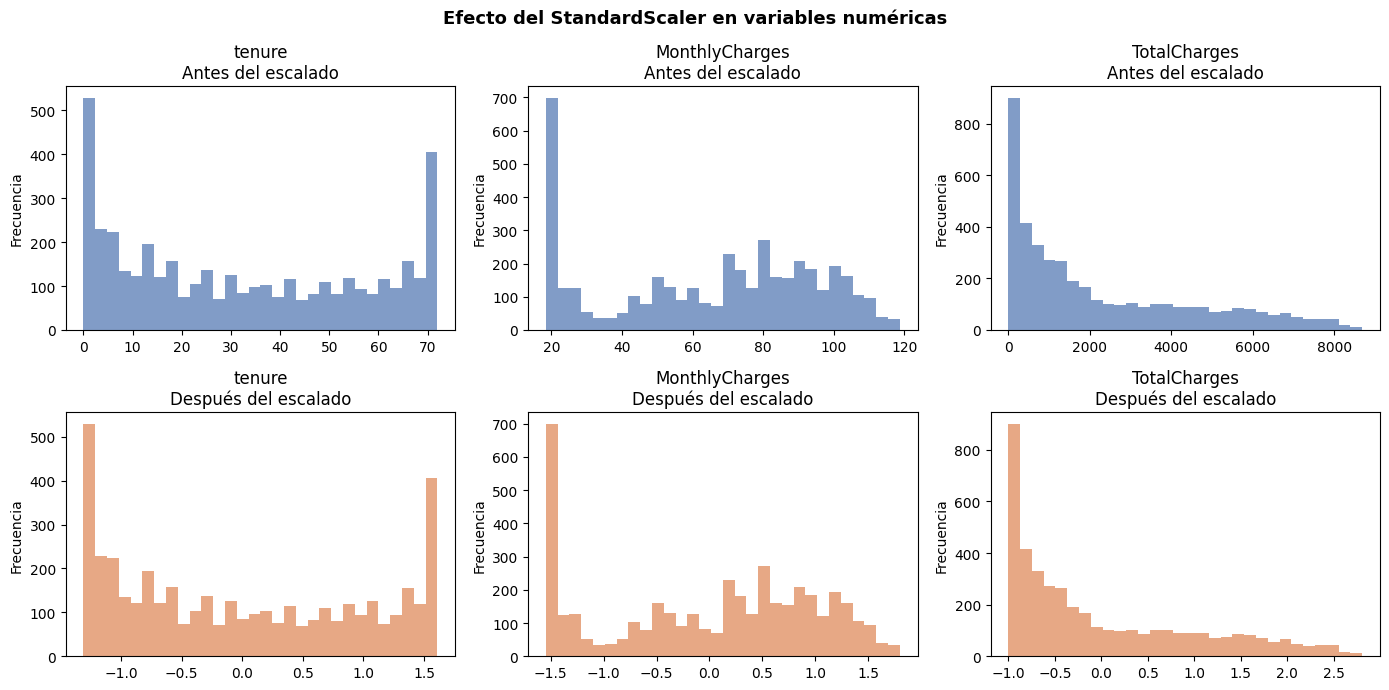

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, col in enumerate(numeric_cols):
    # Antes
    axes[0, i].hist(X_train[col], bins=30, color='#4C72B0', alpha=0.7)
    axes[0, i].set_title(f'{col}\nAntes del escalado')
    axes[0, i].set_ylabel('Frecuencia')

    # Después
    axes[1, i].hist(X_train_scaled[col], bins=30, color='#DD8452', alpha=0.7)
    axes[1, i].set_title(f'{col}\nDespués del escalado')
    axes[1, i].set_ylabel('Frecuencia')

plt.suptitle('Efecto del StandardScaler en variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


La forma de la distribución no cambia, solo la escala.

**¿El Árbol de Decisión necesita escalado?**

Entranemiento de un árbol simple con ambos conjuntos y compración usando el F1-score.

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()

In [10]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Con datos sin escalar
dt.fit(X_train, y_train)
f1_sin = f1_score(y_val, dt.predict(X_val))

# Con datos escalados
dt.fit(X_train_scaled, y_train)
f1_con = f1_score(y_val, dt.predict(X_val_scaled))

In [11]:
print(f'F1-score Árbol SIN escalado: {f1_sin:.4f}')
print(f'F1-score Árbol CON escalado: {f1_con:.4f}')

F1-score Árbol SIN escalado: 0.4722
F1-score Árbol CON escalado: 0.4722


 El Árbol de Decisión (y los algoritmos basados en árboles) es invariante al escalado. Por eso en el notebook de entrenamiento usará los datos originales para este algoritmo.

**Exportar datasets escalados**

In [12]:
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_val_scaled.to_csv('../data/processed/X_val_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)